In [3]:
import h5py
with h5py.File("Data_documenting.mat", "r") as f:
    print(list(f.keys()))


['PSI', 'Rxx_bar', 'di_dry', 'di_water', 'ds', 'exx', 'frac_loc_125m', 'frac_loc_1km', 'vulnerable', 'x', 'y']


(2417, 2089)
0.0 1.0


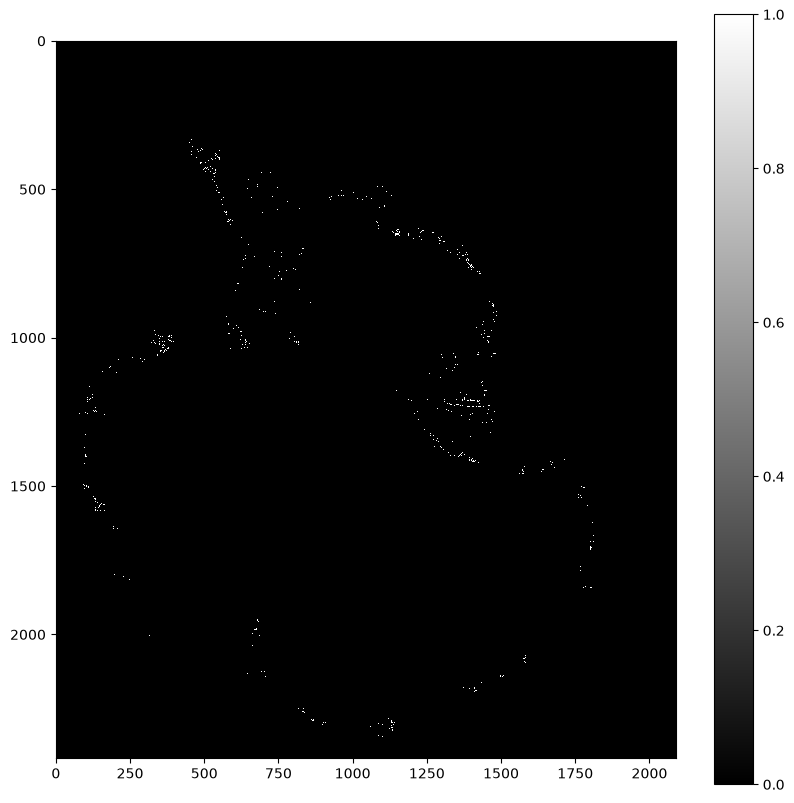

In [ ]:
import h5py
import matplotlib.pyplot as plt

with h5py.File("Data_documenting.mat", "r") as f:
    dataset = f["frac_loc_125m"]

    # Read every 20th row and column



In [4]:
with h5py.File("Data_documenting.mat", "r") as f:
    print(f["x"].shape, f["x"][:5], f["x"][-5:])
    print(f["y"].shape, f["y"][:5], f["y"][-5:])


(1, 5501) [[-2750000. -2749000. -2748000. ...  2748000.  2749000.  2750000.]] [[-2750000. -2749000. -2748000. ...  2748000.  2749000.  2750000.]]
(1, 5501) [[ 2750000.  2749000.  2748000. ... -2748000. -2749000. -2750000.]] [[ 2750000.  2749000.  2748000. ... -2748000. -2749000. -2750000.]]


In [5]:
with h5py.File("Data_documenting.mat", "r") as f:
    for k in f.keys():
        print(k, f[k].shape, f[k].dtype)


PSI (5501, 5501) float64
Rxx_bar (5501, 5501) float64
di_dry (5501, 5501) float64
di_water (5501, 5501) float64
ds (5501, 5501) float64
exx (5501, 5501) float64
frac_loc_125m (48333, 41779) float64
frac_loc_1km (5501, 5501) float64
vulnerable (5501, 5501) float64
x (1, 5501) float64
y (1, 5501) float64


In [5]:
import h5py
import numpy as np
import rasterio
from rasterio.transform import from_origin
from rasterio.windows import Window

h5_path = "Data_documenting.mat"
output_path = "frac_loc_125m_float.tif"

width = 48_333       # x/columns
height = 41_779      # y/rows
resolution = 125.0

# Center coordinate of the upper-left pixel
x_center_ul = -3_174_450.0
y_center_ul = 2_406_325.0

# GeoTIFF transform requires the outer corner, not the pixel center
transform = from_origin(
    x_center_ul - resolution / 2,
    y_center_ul + resolution / 2,
    resolution,
    resolution,
)

with h5py.File(h5_path, "r") as h5:
    src = h5["frac_loc_125m"]

    print("HDF5 shape:", src.shape)
    print("HDF5 dtype:", src.dtype)

    profile = {
        "driver": "GTiff",
        "width": width,
        "height": height,
        "count": 1,
        "dtype": "float64",       # appropriate for a binary fracture mask
        "crs": "EPSG:3031",
        "transform": transform,
        "nodata": 255,          # reserve 255 for missing data
        "compress": "DEFLATE",
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "BIGTIFF": "YES",
    }

    rows_per_block = 512

    with rasterio.open(output_path, "w", **profile) as dst:
        for row_start in range(0, height, rows_per_block):
            row_count = min(rows_per_block, height - row_start)

            if src.shape == (height, width):
                # Already stored as (y, x)
                block = src[row_start : row_start + row_count, :]

            elif src.shape == (width, height):
                # Common when MATLAB arrays are read through h5py
                block = src[:, row_start : row_start + row_count].T

            else:
                raise ValueError(
                    f"Unexpected frac_loc_125m shape {src.shape}; "
                    f"expected {(height, width)} or {(width, height)}"
                )

            # Convert Boolean/binary values to a GeoTIFF-compatible integer type
            block = np.asarray(block, dtype=np.float64)

            dst.write(
                block,
                1,
                window=Window(
                    col_off=0,
                    row_off=row_start,
                    width=width,
                    height=row_count,
                ),
            )

print(f"Created {output_path}")

HDF5 shape: (48333, 41779)
HDF5 dtype: float64
Created frac_loc_125m_float.tif


In [4]:
with rasterio.open("fracture_map_125.tif") as fine, \
     rasterio.open("bedmachinev03_mask.tif") as coarse:

    print("Fine transform:", fine.transform)
    print("Coarse transform:", coarse.transform)

    x_offset = (coarse.transform.c - fine.transform.c) / 125
    y_offset = (coarse.transform.f - fine.transform.f) / 125

    print("Offsets in 125 m pixels:", x_offset, y_offset)

Fine transform: | 125.00, 0.00,-3174450.00|
| 0.00,-125.00, 2406325.00|
| 0.00, 0.00, 1.00|
Coarse transform: | 500.00, 0.00,-3333250.00|
| 0.00,-500.00, 3333250.00|
| 0.00, 0.00, 1.00|
Offsets in 125 m pixels: -1270.4 7415.4


In [ ]:
import h5py
import numpy as np
import rasterio
from rasterio.transform import from_origin

mat_path = "Data_documenting.mat"
out_path = "frac_loc_1km.tif"

with h5py.File(mat_path, "r") as f:
    frac = f["frac_loc_1km"][:].T
    x = f["x"][:].squeeze()
    y = f["y"][:].squeeze()


# Pixel spacing
dx = abs(x[1] - x[0])
dy = abs(y[1] - y[0])

# If y increases upward, flip array so row 0 is northern/top edge
if y[0] < y[-1]:
    frac = np.flipud(frac)
    top = y[-1] + dy / 2
else:
    top = y[0] + dy / 2

left = x[0] - dx / 2

transform = from_origin(left, top, dx, dy)

with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=frac.shape[0],
    width=frac.shape[1],
    count=1,
    dtype=frac.dtype,
    crs="EPSG:3031",
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(frac, 1)

print(f"Saved {out_path}")

37404.0


In [8]:
import numpy as np
import rasterio

vx_path = "vx_500m.tif"
vy_path = "vy_500m.tif"
vx_out = "vx_nan_500m.tif"
vy_out = "vy_nan_500m.tif"
vel_mask_out = "velocity_mask_500.tif"
out_strain = "effective_strain_rate_500.tif"
out_stress = "effective_stress_500.tif"

n = 4
A = 10e-29

SEC_PER_YEAR = 365.25 * 24 * 3600

with rasterio.open(vx_path) as src:
    vx = src.read(1).astype("float64")
    profile = src.profile
    transform = src.transform
    nodata = -32767

with rasterio.open(vy_path) as src:
    vy = src.read(1).astype("float64")


vel_mask = np.isfinite(vx) & np.isfinite(vy)
vel_mask &= (vx != nodata) & (vy != nodata)

with rasterio.open(vel_mask_out, "w", **profile) as dst:
    dst.write(vel_mask.astype("float32"), 1)

vx[~vel_mask] = np.nan
vy[~vel_mask] = np.nan

profile_nan = profile.copy()
profile_nan.update(dtype="float32", nodata=np.nan)

with rasterio.open(vx_out, "w", **profile_nan) as dst:
    dst.write(vx.astype("float32"), 1)

with rasterio.open(vy_out, "w", **profile_nan) as dst:
    dst.write(vy.astype("float32"), 1)

vx = vx / SEC_PER_YEAR
vy = vy / SEC_PER_YEAR

dx = abs(transform.a)
dy = abs(transform.e)

du_dy, du_dx = np.gradient(vx, dy, dx)
dv_dy, dv_dx = np.gradient(vy, dy, dx)

exx = du_dx
eyy = dv_dy
exy = 0.5 * (du_dy + dv_dx)

eff_strain = np.sqrt(0.5 * (exx**2 + eyy**2 + 2 * exy**2))
eff_stress = (eff_strain / A) ** (1 / n)

eff_strain[~vel_mask] = np.nan
eff_stress[~vel_mask] = np.nan

profile.update(dtype="float32", nodata=np.nan)

with rasterio.open(out_strain, "w", **profile) as dst:
    dst.write(eff_strain.astype("float32"), 1)

with rasterio.open(out_stress, "w", **profile) as dst:
    dst.write(eff_stress.astype("float32"), 1)

In [57]:
with rasterio.open("mask_aligned.tif") as src:
    mask = src.read(1)

xmin = -882130.5347
xmax = 872593.9884
ymin = -877362.2616
ymax = 820142.9837

rows, cols = np.indices(mask.shape)

xs = transform.c + (cols + 0.5) * transform.a
ys = transform.f + (rows + 0.5) * transform.e

exclude = (
    (xs >= xmin) & (xs <= xmax) &
    (ys >= ymin) & (ys <= ymax)
)

mask = (mask == 2) | (mask == 3)
# vel_mask &= mask
difference = (mask != vel_mask) & (~exclude)

print(difference.sum())

agreement = ((mask == vel_mask) & (~exclude)).mean()
print(agreement)

TP = np.sum( mask &  vel_mask)
FN = np.sum( mask & ~vel_mask)
FP = np.sum(~mask &  vel_mask)
TN = np.sum(~mask & ~vel_mask)

print("Ice + valid velocity:", TP)
print("Ice + no velocity:", FN)
print("Non-ice + valid velocity:", FP)
print("Non-ice + no velocity:", TN)

274503
0.8924525662584658
Ice + valid velocity: 11834587
Ice + no velocity: 1674650
Non-ice + valid velocity: 256665
Non-ice + no velocity: 16495099


In [50]:
from rasterio.transform import xy

rows, cols = np.where(difference)
i = 1000

print(vel_mask[rows[i]][cols[i]])
print(mask[rows[i]][cols[i]])
x, y = xy(transform, rows[i], cols[i])
print(y, x)


# xs, ys = xy(transform, rows, cols)

# for x, y in zip(xs[:10], ys[:10]):
#     print(x, y)

False
True
2064000.0 786000.0


In [10]:
import numpy as np
import rasterio

fracture_path = "frac_map_500m.tif"
ice_mask_path = "mask_500m.tif"
output_path = "frac_map_500m_on_ice.tif"

with rasterio.open(fracture_path) as fracture_src, \
     rasterio.open(ice_mask_path) as ice_src:

    # Confirm both rasters use the same pixel grid.
    if fracture_src.shape != ice_src.shape:
        raise ValueError(
            f"Shape mismatch: fracture={fracture_src.shape}, "
            f"ice mask={ice_src.shape}"
        )

    if fracture_src.transform != ice_src.transform:
        raise ValueError("The rasters have different transforms.")

    if fracture_src.crs != ice_src.crs:
        raise ValueError("The rasters have different coordinate systems.")

    fractures = fracture_src.read(1)
    ice_mask = ice_src.read(1)
    print(np.count_nonzero(fractures))

    # Adjust this condition if your mask uses different class values.
    on_ice = np.isfinite(ice_mask) & (ice_mask > 0)

    off_ice_fractures = np.count_nonzero(
        (fractures > 0) & ~on_ice
    )
    print("Fracture pixels being removed:", off_ice_fractures)

    fractures_clean = fractures.copy()
    fractures_clean[~on_ice] = 0

    profile = fracture_src.profile.copy()
    

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(fractures_clean, 1)

print(f"Saved {output_path}")

196260
Fracture pixels being removed: 7810
Saved frac_map_500m_on_ice.tif


In [2]:
from dataset import FracturePatchDataset
from load_data import load_data
import numpy as np

X, y = load_data()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X finite:", np.isfinite(X).all())
print("y finite:", np.isfinite(y).all())
print("Predictor range:", X.min(), X.max())
print("Fracture pixels:", np.count_nonzero(y))
print("Ice pixels:", np.count_nonzero(X[7]))
print("Valid velocity pixels:", np.count_nonzero(X[8]))

dataset = FracturePatchDataset(
    X_full=X,
    y_full=y,
    ice_mask=X[7],
    patch_size=64,
    positive_patches=50,
    negative_patches=50,
    seed=42,
)

print("Number of patches:", len(dataset))

X_patch, y_patch = dataset[0]

print("X patch:", X_patch.shape)
print("y patch:", y_patch.shape)
print("Patch finite:", X_patch.isfinite().all().item())

X shape: (9, 10444, 12082)
y shape: (10444, 12082)
X finite: True
y finite: True
Predictor range: -49.19743 42.861748
Fracture pixels: 188450
Ice pixels: 54374435
Valid velocity pixels: 48364542
Number of patches: 100
X patch: torch.Size([9, 64, 64])
y patch: torch.Size([1, 64, 64])
Patch finite: True
